# ACM (MCA) — Telco Customer Churn

**Análisis de correspondencias múltiples** (*Multiple Correspondence Analysis*) sobre el dataset público de churn. Los datos se descargan desde una URL; se excluyen el identificador y las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`). El resto son **solo cualitativas** (incluida `Churn` como categoría más).

Objetivos: reducir dimensionalidad preservando asociaciones χ² entre modalidades, graficar resultados y **comparar** con una PCA aplicada a la misma información codificada en indicadores.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from prince import MCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler

URL = "https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv"
N_COMP = 12
RNG = 42

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 1. Carga y variables cualitativas

In [2]:
raw = pd.read_csv(URL)
raw["TotalCharges"] = pd.to_numeric(raw["TotalCharges"], errors="coerce")
raw = raw.dropna(subset=["TotalCharges"]).reset_index(drop=True)

no_cualitativas = ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in raw.columns if c not in no_cualitativas]
df = raw[cat_cols].astype(str)
churn = raw["Churn"].str.strip()

print("Filas:", len(df), "| Variables categóricas:", len(cat_cols))
df.head(3)

Filas: 7032 | Variables categóricas: 17


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


## 2. ACM (MCA)

`prince.MCA` construye el análisis de correspondencias múltiples: la **inercia** y las distancias entre perfiles respetan la lógica χ² de tablas de contingencia, adecuada para nominales.

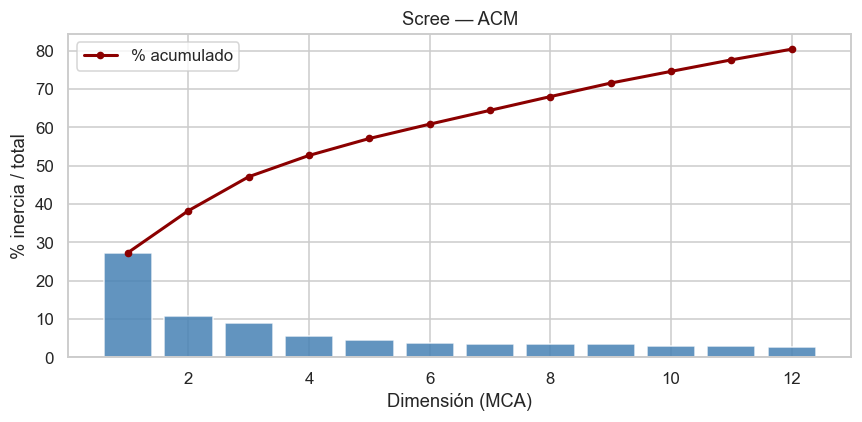

,dim,inercia_%,acum_%
0,1,27.34,27.34
1,2,10.91,38.25
2,3,8.85,47.10
3,4,5.56,52.66
4,5,4.42,57.07
5,6,3.74,60.81
6,7,3.60,64.41
7,8,3.59,68.00


In [3]:
mca = MCA(n_components=N_COMP, random_state=RNG)
coords_mca = mca.fit_transform(df)
eig = mca.eigenvalues_
inercia_pct = 100.0 * eig / mca.total_inertia_
acum_mca = np.cumsum(inercia_pct)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, len(eig) + 1)
ax.bar(x, inercia_pct, color="steelblue", alpha=0.85)
ax.plot(x, acum_mca, "o-", color="darkred", lw=2, markersize=4, label="% acumulado")
ax.set_xlabel("Dimensión (MCA)")
ax.set_ylabel("% inercia / total")
ax.set_title("Scree — ACM")
ax.legend()
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {"dim": x, "inercia_%": np.round(inercia_pct, 2), "acum_%": np.round(acum_mca, 2)}
    ).head(8)
)

### Mapa de filas (clientes) — dimensiones 1 y 2

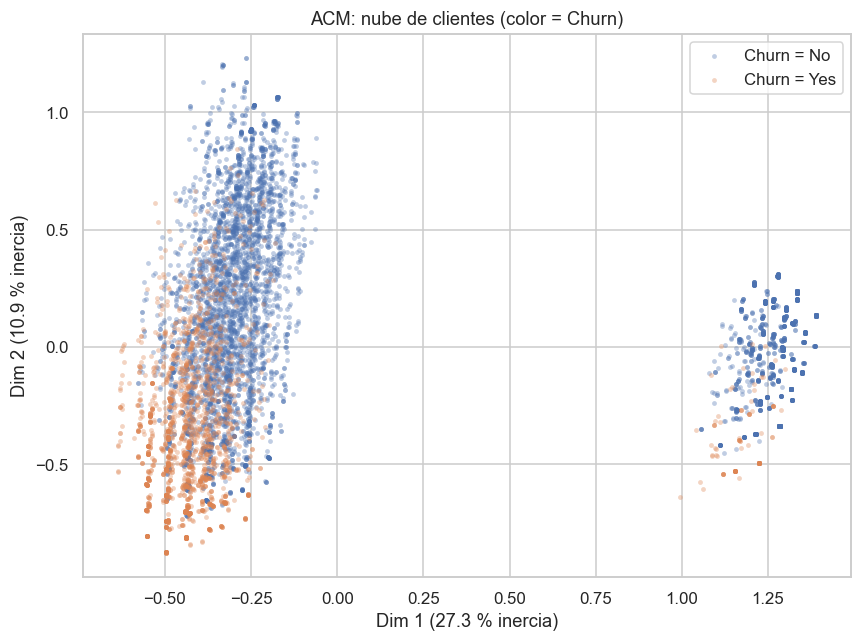

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = {"No": "#4C72B0", "Yes": "#DD8452"}
for lab in ["No", "Yes"]:
    m = churn == lab
    ax.scatter(
        coords_mca.loc[m, 0],
        coords_mca.loc[m, 1],
        s=10,
        alpha=0.35,
        c=palette[lab],
        label=f"Churn = {lab}",
        linewidths=0,
    )
ax.set_xlabel(f"Dim 1 ({inercia_pct[0]:.1f} % inercia)")
ax.set_ylabel(f"Dim 2 ({inercia_pct[1]:.1f} % inercia)")
ax.set_title("ACM: nube de clientes (color = Churn)")
ax.legend()
plt.tight_layout()
plt.show()

### Modalidades categóricas (lectura conjunta con filas)

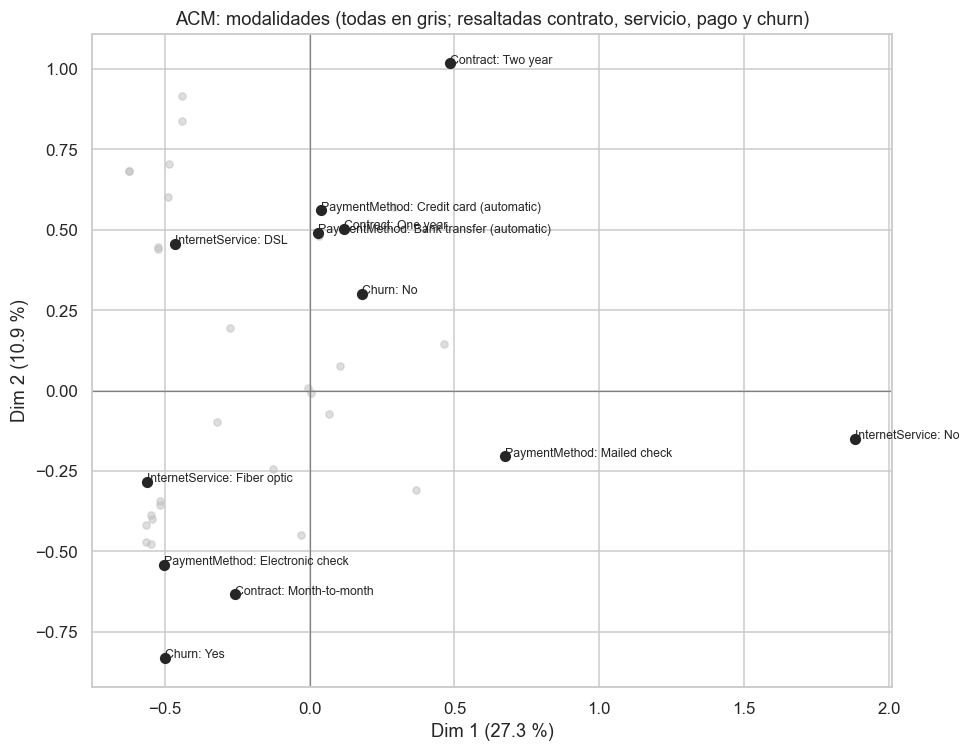

In [5]:
mods = mca.column_coordinates(df)
sel = mods[mods.index.str.startswith(("Churn__", "Contract__", "InternetService__", "PaymentMethod__"))]

fig, ax = plt.subplots(figsize=(9, 7))
ax.axhline(0, c=".5", lw=0.8); ax.axvline(0, c=".5", lw=0.8)
ax.scatter(mods[0], mods[1], s=22, c=".75", alpha=0.5, zorder=1)
ax.scatter(sel[0], sel[1], s=40, c=".15", zorder=2)
for nom, r in sel.iterrows():
    ax.annotate(nom.replace("__", ": "), (r[0], r[1]), fontsize=8)
ax.set(xlabel=f"Dim 1 ({inercia_pct[0]:.1f} %)", ylabel=f"Dim 2 ({inercia_pct[1]:.1f} %)", title="ACM: modalidades (todas en gris; resaltadas contrato, servicio, pago y churn)")
plt.tight_layout(); plt.show()

## 3. PCA de referencia (one-hot + estandarización)

Las mismas columnas categóricas se convierten en **indicadores** (0/1), se centran y escalan, y se aplica **PCA** lineal. Sirve como comparación visual: no sustituye al ACM cuando todas las entradas son nominales.

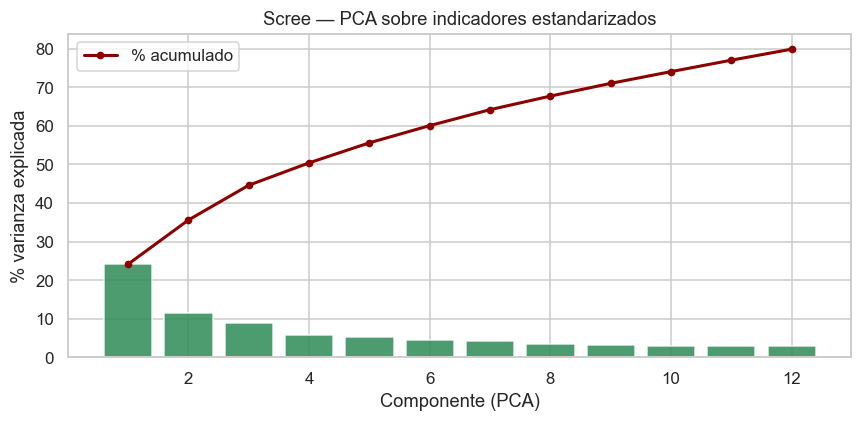

,PC,var_%,acum_%
0,1,24.14,24.14
1,2,11.44,35.58
2,3,9.01,44.58
3,4,5.80,50.38
4,5,5.19,55.58
5,6,4.45,60.03
6,7,4.13,64.16
7,8,3.52,67.67


In [6]:
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
Z = enc.fit_transform(df)
Z = StandardScaler().fit_transform(Z)

pca = PCA(n_components=N_COMP, random_state=RNG)
coords_pca = pca.fit_transform(Z)
var_pca = 100.0 * pca.explained_variance_ratio_
acum_pca = np.cumsum(var_pca)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, len(var_pca) + 1)
ax.bar(x, var_pca, color="seagreen", alpha=0.85)
ax.plot(x, acum_pca, "o-", color="darkred", lw=2, markersize=4, label="% acumulado")
ax.set_xlabel("Componente (PCA)")
ax.set_ylabel("% varianza explicada")
ax.set_title("Scree — PCA sobre indicadores estandarizados")
ax.legend()
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({"PC": x, "var_%": np.round(var_pca, 2), "acum_%": np.round(acum_pca, 2)}).head(8)
)

### Comparación lado a lado: primer plano factorial

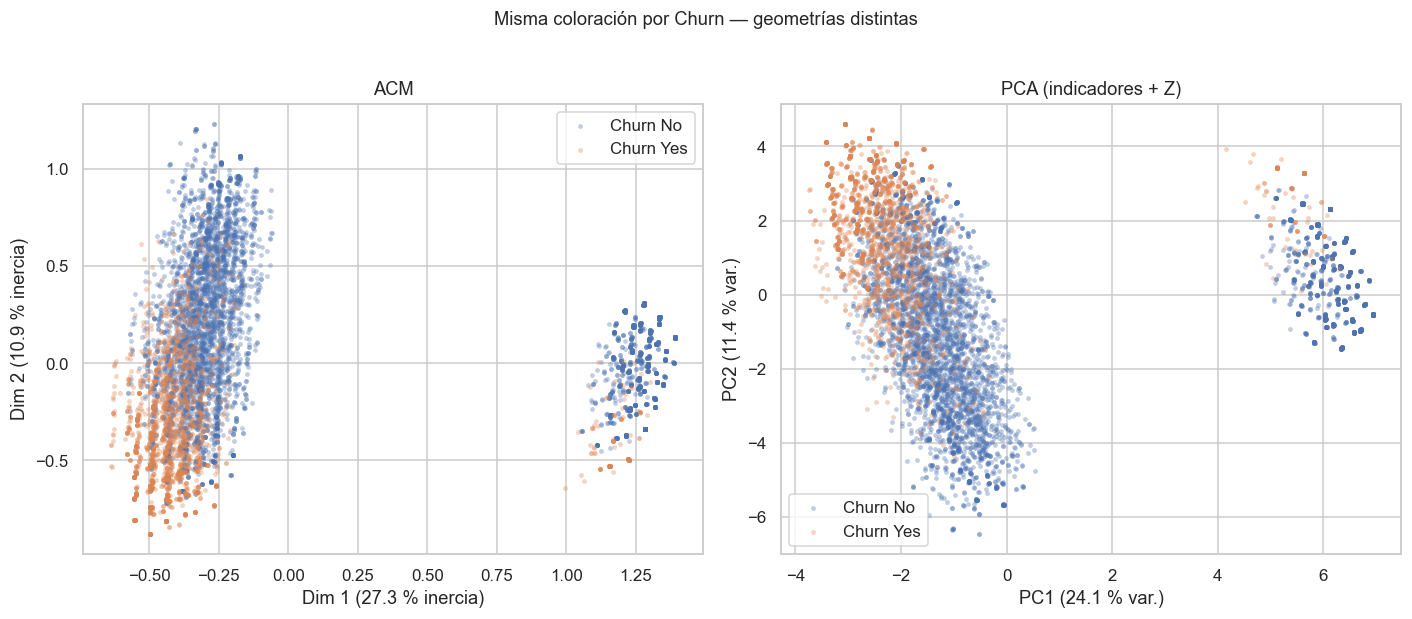

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
palette = {"No": "#4C72B0", "Yes": "#DD8452"}

for lab in ["No", "Yes"]:
    m = churn == lab
    axes[0].scatter(
        coords_mca.loc[m, 0],
        coords_mca.loc[m, 1],
        s=10,
        alpha=0.35,
        c=palette[lab],
        label=f"Churn {lab}",
        linewidths=0,
    )
    axes[1].scatter(
        coords_pca[m.values, 0],
        coords_pca[m.values, 1],
        s=10,
        alpha=0.35,
        c=palette[lab],
        label=f"Churn {lab}",
        linewidths=0,
    )

axes[0].set_xlabel(f"Dim 1 ({inercia_pct[0]:.1f} % inercia)")
axes[0].set_ylabel(f"Dim 2 ({inercia_pct[1]:.1f} % inercia)")
axes[0].set_title("ACM")
axes[1].set_xlabel(f"PC1 ({var_pca[0]:.1f} % var.)")
axes[1].set_ylabel(f"PC2 ({var_pca[1]:.1f} % var.)")
axes[1].set_title("PCA (indicadores + Z)")
axes[0].legend()
axes[1].legend()
plt.suptitle("Misma coloración por Churn — geometrías distintas", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 4. Interpretación y ACM frente a PCA

**ACM.** Maximiza la **inercia** ligada a asociaciones entre categorías (vía χ²). Cercanía entre **filas** (clientes) indica perfiles de respuestas parecidos; la posición de **modalidades** muestra qué categorías contrastan en cada eje. Los ejes se interpretan leyendo categorías extremas (contrato mes a mes vs largo plazo, fibra vs DSL, etc.) en combinación con el mapa de individuos.

**PCA aquí.** Trata cada columna dummy como variable continua estandarizada y busca direcciones de **máxima varianza**. Eso puede mezclar efectos de **frecuencia** (modalidades raras inflan varianza) con la **estructura de asociación** que el ACM modela de forma explícita. Por eso los dos primeros ejes de PCA y de MCA **no tienen por qué coincidir** ni tener la misma escala de distancias.

**Comparación.** Los gráficos comparativos permiten ver si la separación aproximada entre `Churn=Yes` y `Churn=No` es coherente entre métodos. En datos **exclusivamente categóricos**, el **ACM es el enfoque principal**; la **PCA sobre one-hot** es una referencia útil para contrastar qué cambia la geometría cuando se impone un modelo lineal sobre indicadores.

*Fuente de datos:* [telco-customer-churn-by-IBM.csv](https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv) (IBM vía repositorio Plotly).